# Stochastic Gradient Descent, Regularization, and Transfer Learning

# **Assignment 4**
### 10 Points

### Use the code of CNNs that you wrote for Assignment 2 and perform the following tasks on CIFAR10 Images:

#### Q1 and Q2 are worth 5 points together, Q3 and Q4 are worth 5 points together.

1.   Use Gradient Descent and Stochastic Gradient Descent (SGD) as the learning algorithms and compare the performance for 100 epochs of training. Plot the Loss vs Epochs on the same graph.

2.   Using SGD for the same example do the following and comapre the results for each case with the base case done in using SGD in part 1.

          1.   Train your network using SGD with momentum = 0.9
          2.   Train your network using SGD with Dropout
          3.   Train your network using SGD with L2 regularization 
          
   You should be able to compare the training and test performance for all the three cases with the base case. You should provide a detailed explanation for the different results.
   
#### WHAT IS TRANSFER LEARNING?
Transfer learning, used in machine learning, is the reuse of a pre-trained model on a new problem. In transfer learning, a machine exploits the knowledge gained from a previous task to improve generalization about another. For example, in training a classifier to predict whether an image contains food, you could use the knowledge it gained during training to recognize drinks. Because transfer learning involves retraining an existing model with a new dataset, the retrained model will consist of knowledge gained from multiple datasets.

3.   Experiment with different CNN architectures that include: AlexNet, VGG, ResNet, and DenseNet. Fine tune the hyperparameters (Optimizers, batch_size, learning rate, etc.) and compare the performance of these architectures. 
4. Plot the accuracy and loss for all the architectures on the same plots. Conclude which architecture is best suited for the CIFAR10 dataset and explain why the chosen model had the best performance.

# Question 1

In [30]:
import torch
import torch.nn.functional as F
from torch import autograd, nn
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms, datasets
import torch.optim as optim

Mytransform = transforms.Compose([transforms.ToTensor(),transforms.RandomHorizontalFlip(p=0.3)])

trainset = torchvision.datasets.CIFAR10(root='data/train', train=True,
                                        download=True, transform=Mytransform)

testset = torchvision.datasets.CIFAR10(root='data/test', train=False,
                                       download=True, transform=Mytransform)

print('==>>> total training set number: {}'.format(len(trainset)))
print('==>>> total test set number: {}'.format(len(testset)))

==>>> total training set number: 50000
==>>> total test set number: 10000


In [2]:
class Mycnn(nn.Module):
    def __init__(self):
        super(Mycnn, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3) # convolutional layer
        self.fc1 = nn.Linear(64 * 30 * 30, 256) #  64 feature maps * (30 * 30 pixels) * hidden layer with 256 neuron
        self.fc2 = nn.Linear(256, 10) # must output 10 classes

    def forward(self, x):

        x = F.relu(self.conv1(x)) # apply convolution then ReLU
        x = x.view(x.size(0), -1) # flatten feature maps
        x = F.relu(self.fc1(x)) # hidden layer
        x = self.fc2(x) # output layer
        
        return x
    
model = Mycnn()

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda") # Google Colab GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Mac GPU
else:
    device = torch.device("cpu") # CPU
    
print(device)

mps


In [4]:
def train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs):
    
    # Initialize lists
    train_acc_list = []
    valid_acc_list = []
    train_loss_list = []
    valid_loss_list = []

    model.to(device)

    for epoch in range(n_epochs):
        
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            train_correct += (predicted == target).sum().item()
            
        # Validation
        model.eval()
        valid_loss = 0.0
        valid_correct = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                
                valid_loss += loss.item() * data.size(0)
                _, predicted = torch.max(output.data, 1)
                valid_correct += (predicted == target).sum().item()

        # Calculate Averages
        train_loss = train_loss/len(train_loader.dataset)
        train_acc = train_correct/len(train_loader.dataset)
        valid_loss = valid_loss/len(test_loader.dataset)
        valid_acc = valid_correct/len(test_loader.dataset)

        # Print values after each epoch
        print(f'Epoch {epoch+1}/{n_epochs}:')
        print(f'\tTrain Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}')
        print(f'\tValidation Loss: {valid_loss:.4f} | Validation Accuracy: {valid_acc:.4f}')

        # Add values to lists for plotting
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        valid_loss_list.append(valid_loss)
        valid_acc_list.append(valid_acc)

    return train_acc_list, valid_acc_list, train_loss_list, valid_loss_list

In [5]:
import pandas as pd

def save_training_history(train_acc, valid_acc, train_loss, valid_loss, model_name):
    history = pd.DataFrame({
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'valid_loss': valid_loss,
        'valid_accuracy': valid_acc
    })

    history.to_csv(f'training_data/{model_name}_training_data.csv', index=False)

def load_training_history(model_name):
    return pd.read_csv(f'training_data/{model_name}_training_data.csv')

In [6]:
BATCH_SIZE = 512

sgd_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Using a batch_size larger than 4096 causes my laptop to crash, so I can't do true Gradient Descent
# Gradient Descent should use batch_size=len(trainset)
bgd_loader = torch.utils.data.DataLoader(trainset, batch_size=4096, shuffle=False)

test_loader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

n_epochs = 100
learning_rate = 0.01
criterion = nn.CrossEntropyLoss()

In [61]:
print("Training with Stochastic Gradient Descent...")
model_sgd = Mycnn().to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=learning_rate)
train_acc_sgd, test_acc_sgd, train_loss_sgd, test_loss_sgd = train_model(model_sgd, 
                                                                         sgd_loader, 
                                                                         test_loader, 
                                                                         criterion, 
                                                                         optimizer_sgd, 
                                                                         n_epochs)

save_training_history(train_acc_sgd, test_acc_sgd, train_loss_sgd, test_loss_sgd, "sgd_base")

print("\nTraining with Gradient Descent...")
model_gd = Mycnn().to(device)
optimizer_gd = optim.SGD(model_gd.parameters(), lr=learning_rate)
train_acc_gd, test_acc_gd, train_loss_gd, test_loss_gd = train_model(model_gd, 
                                                                     sgd_loader, 
                                                                     test_loader, 
                                                                     criterion, 
                                                                     optimizer_gd, 
                                                                     n_epochs)

save_training_history(train_acc_gd, test_acc_gd, train_loss_gd, test_loss_gd, "gd")

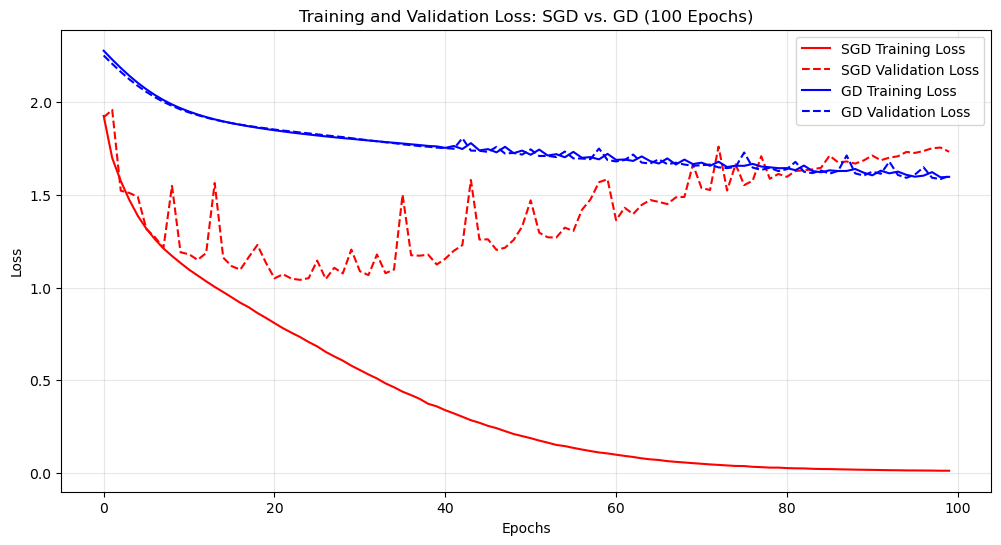

In [62]:
sgd_base = pd.read_csv('training_data/sgd_base_training_data.csv')
gd = pd.read_csv('training_data/gd_training_data.csv')

plt.figure(figsize=(12, 6))

plt.plot(sgd_base['train_loss'], label='SGD Training Loss', color='red', linestyle='-')
plt.plot(sgd_base['valid_loss'], label='SGD Validation Loss', color='red', linestyle='--')

plt.plot(gd['train_loss'], label='GD Training Loss', color='blue', linestyle='-')
plt.plot(gd['valid_loss'], label='GD Validation Loss', color='blue', linestyle='--')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss: SGD vs. GD (100 Epochs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Validation loss minimizes for Stochastic Gradient Descent (SGD) minimizes at epoch 23, whereas 100 epochs is not enough for the validation loss for Gradient Descent (GD) to reach its minimum. Training loss decreases much more quickly for SGD than GD.

# Question 2

In [8]:
print("Training with SGD with Momentum = 0.9...")
model_mom = Mycnn().to(device)
optimizer_mom = optim.SGD(model_mom.parameters(), lr=learning_rate, momentum=0.9)
train_acc_mom, test_acc_mom, train_loss_mom, test_loss_mom = train_model(model_mom, 
                                                                         sgd_loader, 
                                                                         test_loader, 
                                                                         criterion, 
                                                                         optimizer_mom, 
                                                                         n_epochs)

save_training_history(train_acc_mom, test_acc_mom, train_loss_mom, test_loss_mom, "sgd_mom")

print("\nTraining with SGD with Dropout...")
model_dropout = nn.Sequential(nn.Dropout(p=0.5), Mycnn()).to(device)
optimizer_dropout = optim.SGD(model_dropout.parameters(), lr=learning_rate)
train_acc_dropout, test_acc_dropout, train_loss_dropout, test_loss_dropout = train_model(model_dropout, 
                                                                                         sgd_loader, 
                                                                                         test_loader, 
                                                                                         criterion, 
                                                                                         optimizer_dropout, 
                                                                                         n_epochs)

save_training_history(train_acc_dropout, test_acc_dropout, train_loss_dropout, test_loss_dropout, "sgd_dropout")

print("\nTraining with SGD with L2 Regularization...")
model_l2 = Mycnn().to(device)
optimizer_l2 = optim.SGD(model_l2.parameters(), lr=learning_rate, weight_decay=1e-4)
train_acc_l2, test_acc_l2, train_loss_l2, test_loss_l2 = train_model(model_l2, 
                                                                     sgd_loader, 
                                                                     test_loader, 
                                                                     criterion, 
                                                                     optimizer_l2, 
                                                                     n_epochs)

save_training_history(train_acc_l2, test_acc_l2, train_loss_l2, test_loss_l2, "sgd_l2")

Training with SGD with Momentum = 0.9...
Epoch 1/100:
	Train Loss: 1.6632 | Train Accuracy: 0.4018
	Validation Loss: 1.3682 | Validation Accuracy: 0.5064
Epoch 2/100:
	Train Loss: 1.3007 | Train Accuracy: 0.5372
	Validation Loss: 1.2251 | Validation Accuracy: 0.5598
Epoch 3/100:
	Train Loss: 1.1590 | Train Accuracy: 0.5916
	Validation Loss: 1.1719 | Validation Accuracy: 0.5900
Epoch 4/100:
	Train Loss: 1.0541 | Train Accuracy: 0.6245
	Validation Loss: 1.1629 | Validation Accuracy: 0.5880
Epoch 5/100:
	Train Loss: 0.9655 | Train Accuracy: 0.6600
	Validation Loss: 1.1213 | Validation Accuracy: 0.6112
Epoch 6/100:
	Train Loss: 0.8904 | Train Accuracy: 0.6876
	Validation Loss: 1.1305 | Validation Accuracy: 0.6180
Epoch 7/100:
	Train Loss: 0.8170 | Train Accuracy: 0.7125
	Validation Loss: 1.1444 | Validation Accuracy: 0.6128
Epoch 8/100:
	Train Loss: 0.7470 | Train Accuracy: 0.7419
	Validation Loss: 1.1245 | Validation Accuracy: 0.6346
Epoch 9/100:
	Train Loss: 0.6804 | Train Accuracy: 0.76

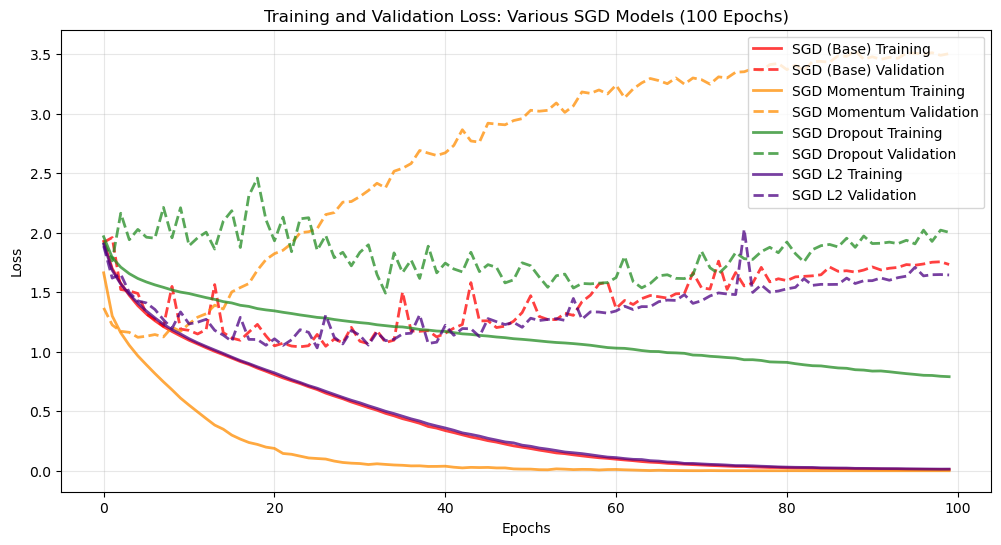

In [65]:
sgd_mom = pd.read_csv('training_data/sgd_mom_training_data.csv')
sgd_dropout = pd.read_csv('training_data/sgd_dropout_training_data.csv')
sgd_l2 = pd.read_csv('training_data/sgd_l2_training_data.csv')

plt.figure(figsize=(12, 6))

a = 0.75
line_width = 2

# SGD Base (Required Red)
plt.plot(sgd_base['train_loss'], label='SGD (Base) Training', color='red', ls='-', lw=line_width, alpha=a)
plt.plot(sgd_base['valid_loss'], label='SGD (Base) Validation', color='red', ls='--', lw=line_width, alpha=a)

# SGD Momentum
plt.plot(sgd_mom['train_loss'], label='SGD Momentum Training', color='darkorange', ls='-', lw=line_width, alpha=a)
plt.plot(sgd_mom['valid_loss'], label='SGD Momentum Validation', color='darkorange', ls='--', lw=line_width, alpha=a)

# SGD Dropout
plt.plot(sgd_dropout['train_loss'], label='SGD Dropout Training', color='forestgreen', ls='-', lw=line_width, alpha=a)
plt.plot(sgd_dropout['valid_loss'], label='SGD Dropout Validation', color='forestgreen', ls='--', lw=line_width, alpha=a)

# SGD L2
plt.plot(sgd_l2['train_loss'], label='SGD L2 Training', color='indigo', ls='-', lw=line_width, alpha=a)
plt.plot(sgd_l2['valid_loss'], label='SGD L2 Validation', color='indigo', ls='--', lw=line_width, alpha=a)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss: Various SGD Models (100 Epochs)')
plt.legend(loc=1)
plt.grid(True, alpha=0.3)
plt.show()

The inclusion of Momentum (0.9) serves as an accelerator, allowing the model to accumulate "velocity" from previous gradients to bypass flat regions of the loss landscape. This explains the rapid convergence at epoch 5, though the higher minimum suggests the optimizer's inertia caused it to overshoot the absolute global minimum in favor of a broader, shallower basin.

In contrast, L2 Regularization acted as a subtle weight penalty, so it mirrored the base model’s performance, indicating that the original architecture was already relatively stable and did not require aggressive weight decay to prevent overfitting.

The Dropout (p=0.5) model exhibited the most instability and the slowest training progress because it essentially forces the network to learn redundant representations by randomly deactivating half the neurons. This introduces noise and prevents the model from reaching the same performance as the base model.

The Base and L2 models achieved the lowest validaiton loss.

# Question 3

In [43]:
import torchvision.models as models
import gc

transform = transforms.Compose([
    transforms.Resize(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# List of CNN architectures to compare
architectures = ['alexnet', 'vgg', 'resnet', 'densenet']

# Hyperparameters to test in the experiment grid
optimizers_list = ["SGD", "Adam"]
batch_sizes = [32, 128]
learning_rates = [0.001, 0.0005]

def get_model(name):
    if name == 'alexnet':
        model = models.alexnet(num_classes=10)
    elif name == 'vgg':
        model = models.vgg11_bn(num_classes=10)
    elif name == 'resnet':
        model = models.resnet18(num_classes=10)
    elif name == 'densenet':
        model = models.densenet121(num_classes=10)
    return model.to(device)

# Nested loop to run every combination
for bt in batch_sizes:

    # Create data loaders for the current batch size
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=bt, shuffle=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=bt, shuffle=False)
    
    for arch_name in architectures:
        for lr in learning_rates:
            for opt_name in optimizers_list:
    
                # Generate a clean filename
                lr_str = str(lr).replace('.', 'p')
                full_model_name = f"{arch_name}_{opt_name}_B-{bt}_lr-{lr_str}"
                
                print(f"\n>>> STARTING: {full_model_name}")
                
                model = get_model(arch_name)
                
                if opt_name == "Adam":
                    optimizer = optim.Adam(model.parameters(), lr=lr)
                else:
                    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
                
                train_acc, valid_acc, train_loss, valid_loss = train_model(model, trainloader, testloader, criterion, optimizer, n_epochs=5)
                
                save_training_history(train_acc, valid_acc, train_loss, valid_loss, full_model_name)
                
                del model
                del optimizer
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                
                print(f">>> FINISHED: {full_model_name}\n")

In [66]:
# Commented out lines represent models that failed during training because of insufficient space on my GPU

# AlexNet
alex_adam_b32_001 = pd.read_csv('training_data/alexnet_Adam_B-32_lr-0p001_training_data.csv')
alex_adam_b32_0005 = pd.read_csv('training_data/alexnet_Adam_B-32_lr-0p0005_training_data.csv')
alex_sgd_b32_001 = pd.read_csv('training_data/alexnet_SGD_B-32_lr-0p001_training_data.csv')
alex_sgd_b32_0005 = pd.read_csv('training_data/alexnet_SGD_B-32_lr-0p0005_training_data.csv')
alex_adam_b128_001 = pd.read_csv('training_data/alexnet_Adam_B-128_lr-0p001_training_data.csv')
alex_adam_b128_0005 = pd.read_csv('training_data/alexnet_Adam_B-128_lr-0p0005_training_data.csv')
alex_sgd_b128_001 = pd.read_csv('training_data/alexnet_SGD_B-128_lr-0p001_training_data.csv')
alex_sgd_b128_0005 = pd.read_csv('training_data/alexnet_SGD_B-128_lr-0p0005_training_data.csv')

# VGG
vgg_adam_b32_001 = pd.read_csv('training_data/vgg_Adam_B-32_lr-0p001_training_data.csv')
vgg_adam_b32_0005 = pd.read_csv('training_data/vgg_Adam_B-32_lr-0p0005_training_data.csv')
vgg_sgd_b32_001 = pd.read_csv('training_data/vgg_SGD_B-32_lr-0p001_training_data.csv')
vgg_sgd_b32_0005 = pd.read_csv('training_data/vgg_SGD_B-32_lr-0p0005_training_data.csv')
vgg_adam_b128_001 = pd.read_csv('training_data/vgg_Adam_B-128_lr-0p001_training_data.csv')
# vgg_adam_b128_0005 = pd.read_csv('training_data/vgg_Adam_B-128_lr-0p0005_training_data.csv')
vgg_sgd_b128_001 = pd.read_csv('training_data/vgg_SGD_B-128_lr-0p001_training_data.csv')
# vgg_sgd_b128_0005 = pd.read_csv('training_data/vgg_SGD_B-128_lr-0p0005_training_data.csv')

# ResNet
res_adam_b32_001 = pd.read_csv('training_data/resnet_Adam_B-32_lr-0p001_training_data.csv')
res_adam_b32_0005 = pd.read_csv('training_data/resnet_Adam_B-32_lr-0p0005_training_data.csv')
res_sgd_b32_001 = pd.read_csv('training_data/resnet_SGD_B-32_lr-0p001_training_data.csv')
res_sgd_b32_0005 = pd.read_csv('training_data/resnet_SGD_B-32_lr-0p0005_training_data.csv')
res_adam_b128_001 = pd.read_csv('training_data/resnet_Adam_B-128_lr-0p001_training_data.csv')
res_adam_b128_0005 = pd.read_csv('training_data/resnet_Adam_B-128_lr-0p0005_training_data.csv')
res_sgd_b128_001 = pd.read_csv('training_data/resnet_SGD_B-128_lr-0p001_training_data.csv')
res_sgd_b128_0005 = pd.read_csv('training_data/resnet_SGD_B-128_lr-0p0005_training_data.csv')

# DenseNet
dense_adam_b32_001 = pd.read_csv('training_data/densenet_Adam_B-32_lr-0p001_training_data.csv')
dense_adam_b32_0005 = pd.read_csv('training_data/densenet_Adam_B-32_lr-0p0005_training_data.csv')
dense_sgd_b32_001 = pd.read_csv('training_data/densenet_SGD_B-32_lr-0p001_training_data.csv')
dense_sgd_b32_0005 = pd.read_csv('training_data/densenet_SGD_B-32_lr-0p0005_training_data.csv')
# dense_adam_b128_001 = pd.read_csv('training_data/densenet_Adam_B-128_lr-0p001_training_data.csv')
# dense_adam_b128_0005 = pd.read_csv('training_data/densenet_Adam_B-128_lr-0p0005_training_data.csv')
# dense_sgd_b128_001 = pd.read_csv('training_data/densenet_SGD_B-128_lr-0p001_training_data.csv')
# dense_sgd_b128_0005 = pd.read_csv('training_data/densenet_SGD_B-128_lr-0p0005_training_data.csv')

In [75]:
experiments = [
    (alex_adam_b32_001, "AlexNet", "Adam", 32, 0.001),
    (alex_adam_b32_0005, "AlexNet", "Adam", 32, 0.0005),
    (alex_sgd_b32_001, "AlexNet", "SGD", 32, 0.001),
    (alex_sgd_b32_0005, "AlexNet", "SGD", 32, 0.0005),
    (alex_adam_b128_001, "AlexNet", "Adam", 128, 0.001),
    (alex_adam_b128_0005, "AlexNet", "Adam", 128, 0.0005),
    (alex_sgd_b128_001, "AlexNet", "SGD", 128, 0.001),
    (alex_sgd_b128_0005, "AlexNet", "SGD", 128, 0.0005),
    
    (vgg_adam_b32_001, "VGG", "Adam", 32, 0.001),
    (vgg_adam_b32_0005, "VGG", "Adam", 32, 0.0005),
    (vgg_sgd_b32_001, "VGG", "SGD", 32, 0.001),
    (vgg_sgd_b32_0005, "VGG", "SGD", 32, 0.0005),
    (vgg_adam_b128_001, "VGG", "Adam", 128, 0.001),
    (vgg_sgd_b128_001, "VGG", "SGD", 128, 0.001),
    
    (res_adam_b32_001, "ResNet", "Adam", 32, 0.001),
    (res_adam_b32_0005, "ResNet", "Adam", 32, 0.0005),
    (res_sgd_b32_001, "ResNet", "SGD", 32, 0.001),
    (res_sgd_b32_0005, "ResNet", "SGD", 32, 0.0005),
    (res_adam_b128_001, "ResNet", "Adam", 128, 0.001),
    (res_adam_b128_0005, "ResNet", "Adam", 128, 0.0005),
    (res_sgd_b128_001, "ResNet", "SGD", 128, 0.001),
    (res_sgd_b128_0005, "ResNet", "SGD", 128, 0.0005),
    
    (dense_adam_b32_001, "DenseNet", "Adam", 32, 0.001),
    (dense_adam_b32_0005, "DenseNet", "Adam", 32, 0.0005),
    (dense_sgd_b32_001, "DenseNet", "SGD", 32, 0.001),
    (dense_sgd_b32_0005, "DenseNet", "SGD", 32, 0.0005)
]

summary_data = []

for df, arch, opt, batch, lr in experiments:
    
    acc = df['valid_accuracy'].iloc[-1]
    loss = df['valid_loss'].iloc[-1]
    
    summary_data.append({
        "Architecture": arch,
        "Optimizer": opt,
        "Batch Size": batch,
        "LR": lr,
        "Loss": loss,
        "Accuracy": acc
    })

performance_summary = pd.DataFrame(summary_data)

# Sort by accuracy to see the best performers at the top
performance_summary = performance_summary.sort_values(by="Loss", ascending=True).reset_index(drop=True)

print(performance_summary)

   Architecture Optimizer  Batch Size      LR      Loss  Accuracy
0      DenseNet      Adam          32  0.0010  0.454940    0.8414
1      DenseNet      Adam          32  0.0005  0.456173    0.8420
2        ResNet      Adam          32  0.0010  0.492836    0.8320
3        ResNet      Adam         128  0.0005  0.566839    0.8091
4        ResNet      Adam          32  0.0005  0.591408    0.7986
5           VGG      Adam          32  0.0005  0.691408    0.7646
6       AlexNet      Adam         128  0.0005  0.715900    0.7605
7           VGG       SGD          32  0.0010  0.743925    0.7411
8           VGG       SGD          32  0.0005  0.784962    0.7261
9        ResNet       SGD          32  0.0010  0.828924    0.7094
10     DenseNet       SGD          32  0.0010  0.882163    0.6859
11          VGG       SGD         128  0.0010  0.893082    0.6803
12       ResNet       SGD          32  0.0005  0.895493    0.6787
13      AlexNet      Adam          32  0.0005  0.902034    0.6840
14      Al

The performance_summary dataframe above shows the validation loss and accuracy for all experiments that could be successfully run with my GPU, sorted by validation loss (ascending).

In [86]:
best_per_arch_indices = performance_summary.groupby('Architecture')['Loss'].idxmin()
best_per_arch = performance_summary.loc[best_per_arch_indices].reset_index(drop=True)
best_per_arch = best_per_arch.sort_values(by="Loss", ascending=True).reset_index(drop=True)

print(best_per_arch)

  Architecture Optimizer  Batch Size      LR      Loss  Accuracy
0     DenseNet      Adam          32  0.0010  0.454940    0.8414
1       ResNet      Adam          32  0.0010  0.492836    0.8320
2          VGG      Adam          32  0.0005  0.691408    0.7646
3      AlexNet      Adam         128  0.0005  0.715900    0.7605


The best_per_arch dataframe above shows best validation loss and accuracy (group by Architecture) among experiments that could be successfully run with my GPU, sorted by validation loss (ascending).

# Question 4

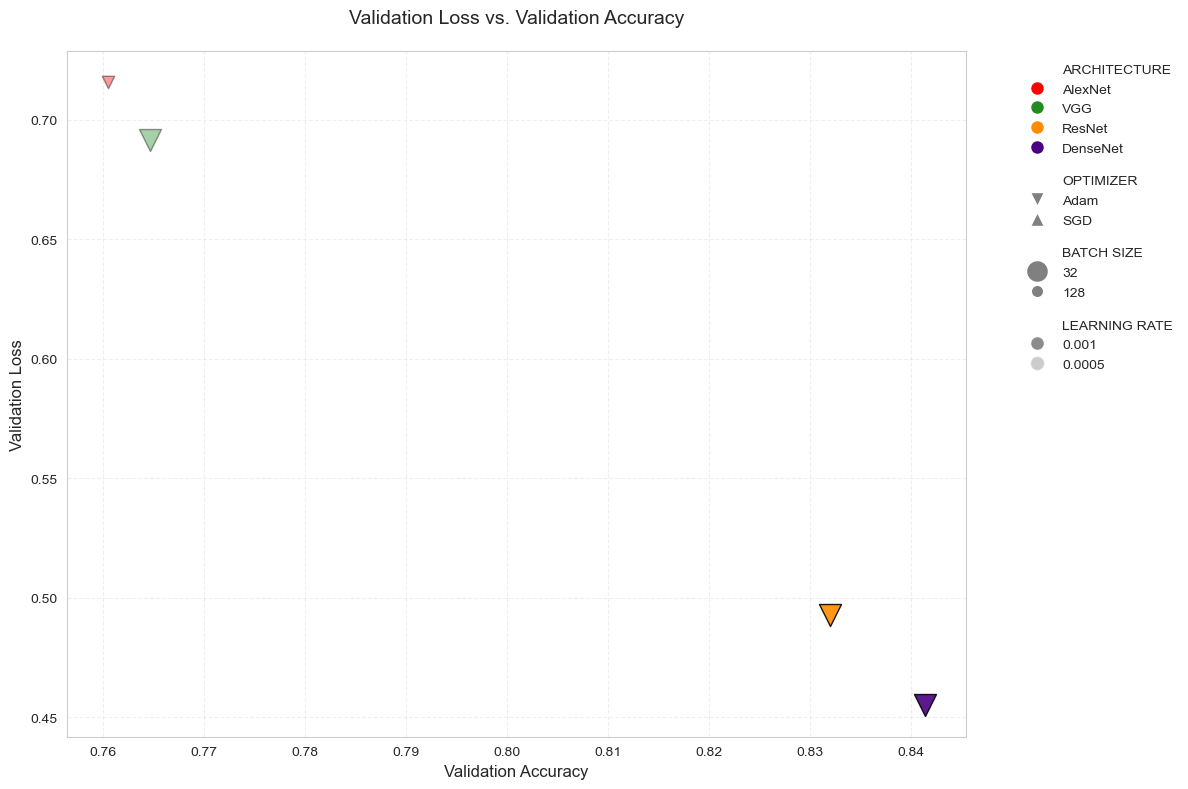

In [90]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))

# Architectures -> Colours
arch_map = {
    'AlexNet': 'red',
    'VGG': 'forestgreen',
    'ResNet': 'darkorange',
    'DenseNet': 'indigo'
}

# Optimizer -> Markers
opt_map = {
    'Adam': 'v',
    'SGD': '^'
}

# Batch Size -> Size
size_map = {32: 250, 128: 80} 

# LR -> Alpha
alpha_map = {0.001: 0.9, 0.0005: 0.4}

# Plotting
for i, row in best_per_arch.iterrows():
    plt.scatter(
        row['Accuracy'], 
        row['Loss'], 
        color=arch_map[row['Architecture']],
        marker=opt_map[row['Optimizer']],
        s=size_map[row['Batch Size']],
        alpha=alpha_map[row['LR']],
        edgecolors='black',
        linewidths=1
    )

legend_elements = []

# Architectures (Colours)
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='ARCHITECTURE', markerfacecolor='w', markersize=0))
for arch, color in arch_map.items():
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=arch, markerfacecolor=color, markersize=10))

# Optimizers (Markers)
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='\nOPTIMIZER', markerfacecolor='w', markersize=0))
for opt, marker in opt_map.items():
    legend_elements.append(Line2D([0], [0], marker=marker, color='w', label=opt, markerfacecolor='gray', markersize=10))

# Batch Size (Size)
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='\nBATCH SIZE', markerfacecolor='w', markersize=0))
for b_size, pt_size in size_map.items():
    # Scale down pt_size for legend display consistency
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=f'{b_size}', markerfacecolor='gray', markersize=pt_size**0.5))

#Learning Rate (Transparency)
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='\nLEARNING RATE', markerfacecolor='w', markersize=0))
for lr, alpha in alpha_map.items():
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=f'{lr}', markerfacecolor='gray', alpha=alpha, markersize=10))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.title('Validation Loss vs. Validation Accuracy', fontsize=14, pad=20)
plt.xlabel('Validation Accuracy', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

After doing hyperparameter tuning on AlexNet, VGG, ResNet, and DenseNet architectures, the plot above shows that DenseNet is best suited for the CIFAR10 dataset since it has the lowest loss and largest accuracy. DenseNet being the best makes sense because it concatenates every layer's output to all subsequent layers, ensuring maximum feature reuse. This is particularly useful for small images like the 32×32 pixel images in CIFAR-10.